## ***Import Libraries***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

***Load Dataset***

In [3]:
df = pd.read_csv('cleaned_sales_dataset.csv')

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Sales_Per_Unit
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2829.77
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,27906.16
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,37491.06
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,28541.36
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,14036.59


***Dataset Overview***

In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.info()

Shape: (1000, 13)

Columns:
Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age',
       'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales', 'Sales_Per_Unit'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        1000 non-null   object 
 1   Order_Date      1000 non-null   object 
 2   Customer_ID     1000 non-null   object 
 3   Customer_Name   1000 non-null   object 
 4   Age             1000 non-null   float64
 5   Gender          1000 non-null   object 
 6   City            1000 non-null   object 
 7   Product         1000 non-null   object 
 8   Category        1000 non-null   object 
 9   Quantity        1000 non-null   int64  
 10  Unit_Price      1000 non-null   float64
 11  Total_Sales     1000 non-null   float64
 12  Sales_Per_Unit  1000 n

***Statistical***

In [5]:
df.describe()

,Age,Quantity,Unit_Price,Total_Sales,Sales_Per_Unit
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.353000,5.435000,25486.783410,139399.439650,25486.783410
std,13.683626,2.838632,14179.402361,114100.051546,14179.402361
min,18.000000,1.000000,145.780000,437.340000,145.780000
25%,30.000000,3.000000,13895.722500,47066.632500,13895.722500
50%,41.000000,5.000000,25398.740000,108594.025000,25398.740000
75%,53.000000,8.000000,37512.382500,203722.882500,37512.382500
max,65.000000,10.000000,49997.530000,493677.500000,49997.530000


In [6]:
top_products = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)

top_products.head(5)

,Total_Sales
Product,
Laptop,25443008.51
Mobile,25335573.19
Book,25031689.40
Rice,22231711.28
Chair,21521561.48


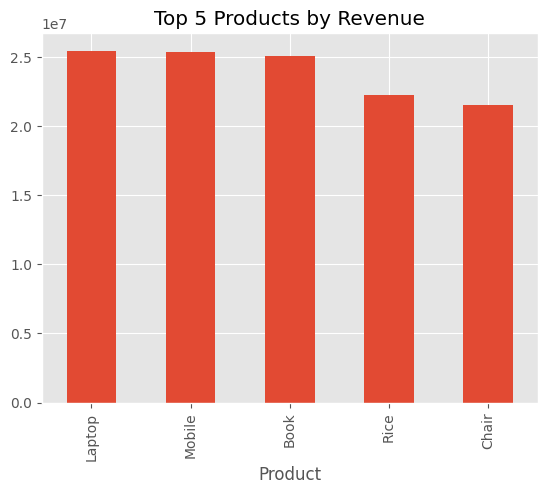

In [7]:
top_products.head(5).plot(kind='bar')
plt.title('Top 5 Products by Revenue')
plt.show()

In [8]:
city_sales = df.groupby('City')['Total_Sales'].sum().sort_values(ascending=False)

city_sales.head()

,Total_Sales
City,
Patna,20826584.43
Kolkata,18884349.57
Bengaluru,18773574.32
Mumbai,18757050.17
Hyderabad,17166766.87


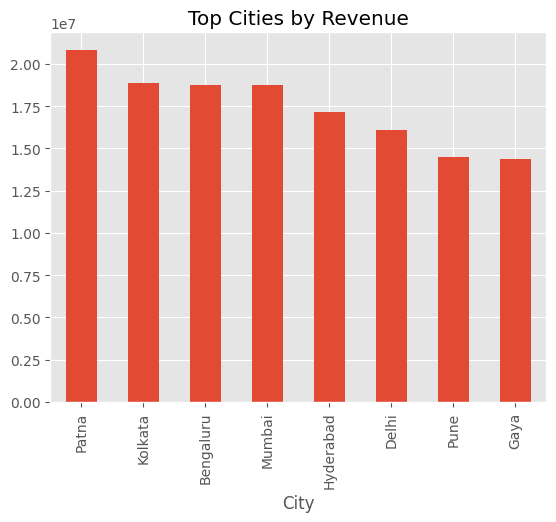

In [9]:
city_sales.head(10).plot(kind='bar')
plt.title('Top Cities by Revenue')
plt.show()

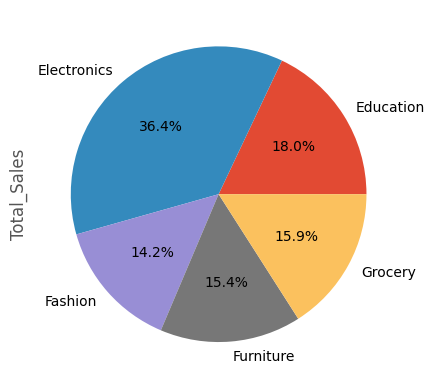

In [10]:
category_sales = df.groupby('Category')['Total_Sales'].sum()

category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.show()

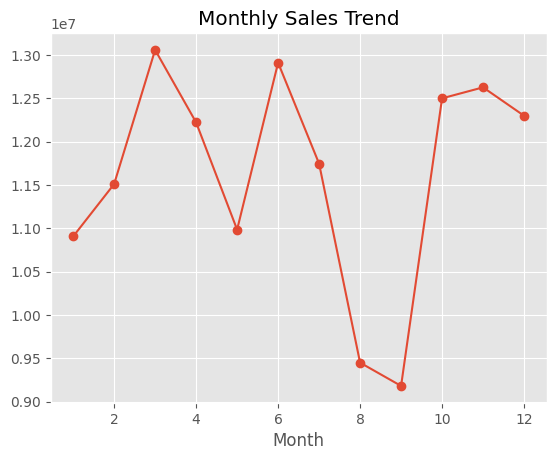

In [11]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df['Month'] = df['Order_Date'].dt.month

monthly_sales = df.groupby('Month')['Total_Sales'].sum()

monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.show()

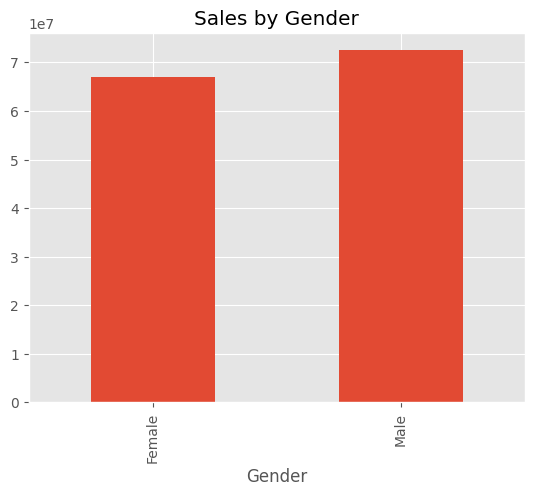

In [12]:
gender_sales = df.groupby('Gender')['Total_Sales'].sum()

gender_sales.plot(kind='bar')
plt.title('Sales by Gender')
plt.show()

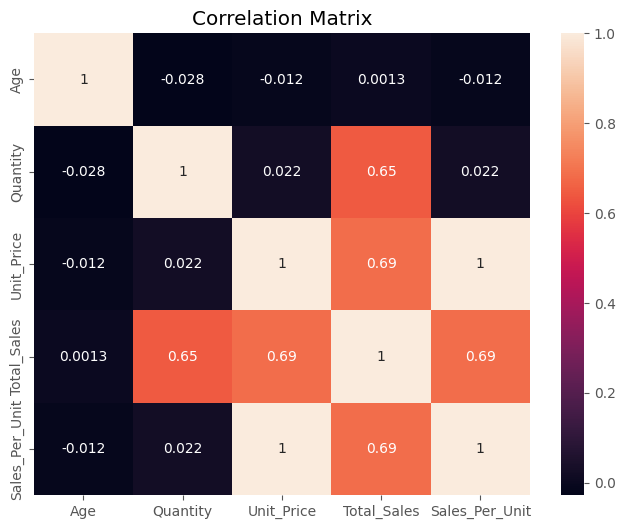

In [13]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

# ***EDA Visualizations***

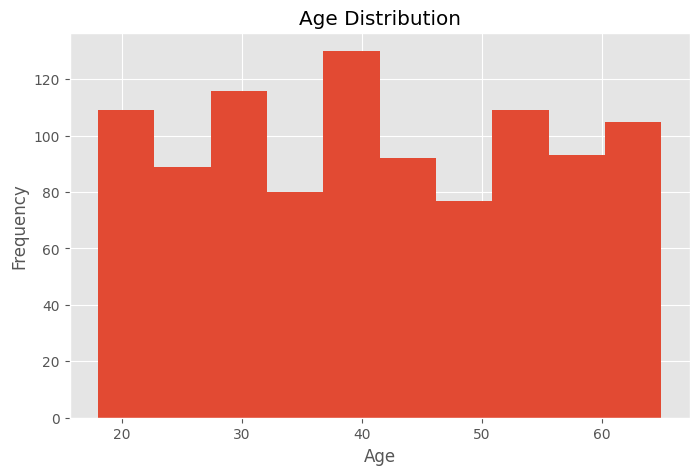

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

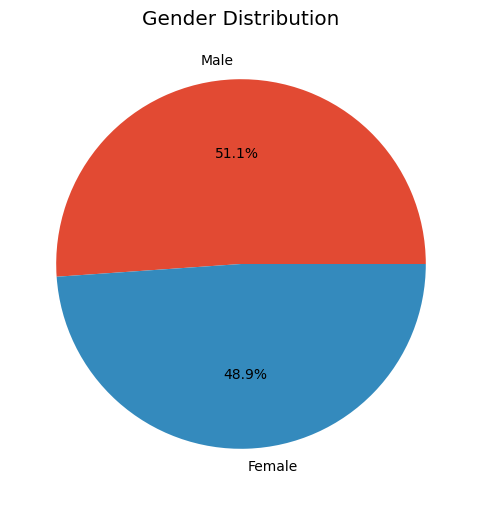

In [15]:
plt.figure(figsize=(6,6))
df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

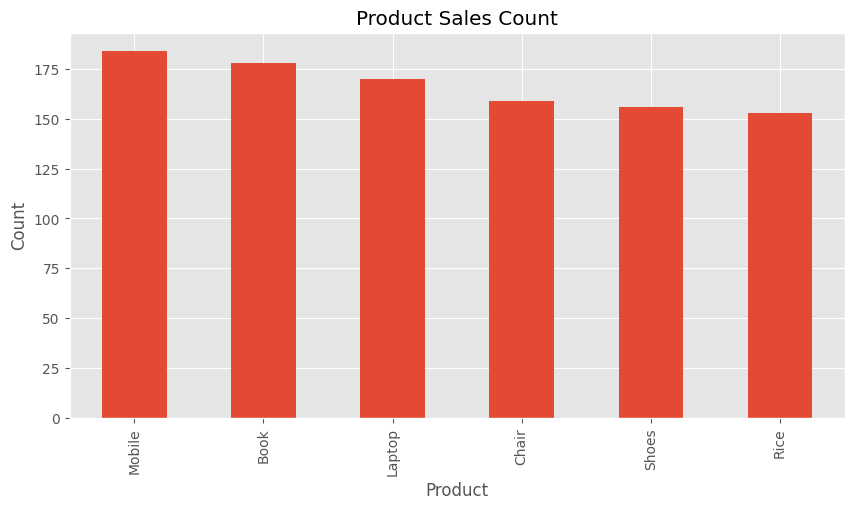

In [16]:
plt.figure(figsize=(10,5))
df['Product'].value_counts().plot(kind='bar')
plt.title('Product Sales Count')
plt.xlabel('Product')
plt.ylabel('Count')
plt.show()

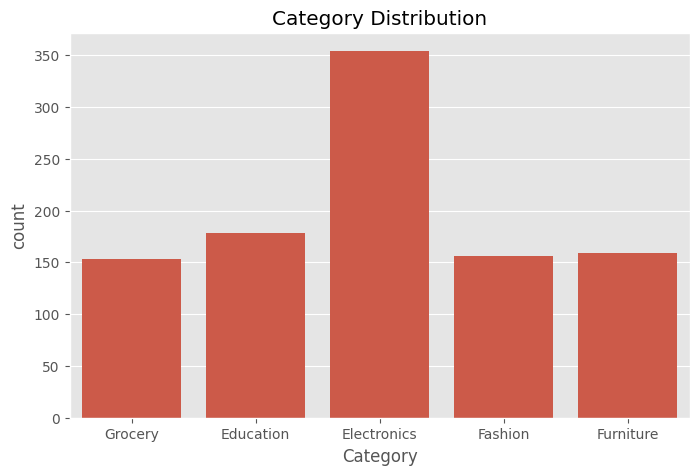

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x='Category', data=df)
plt.title('Category Distribution')
plt.show()

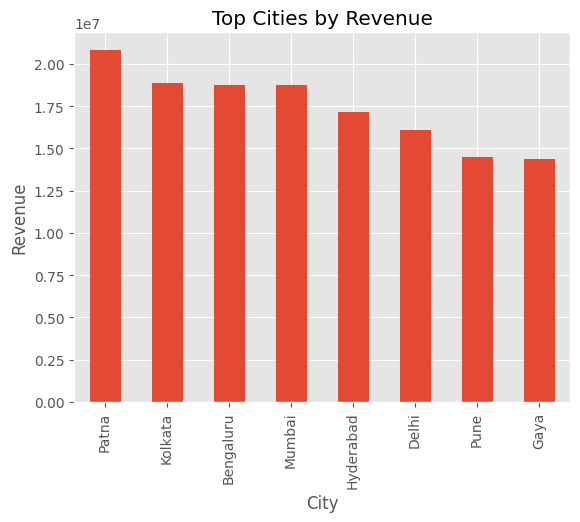

In [18]:
city_sales = df.groupby('City')['Total_Sales'].sum()

city_sales.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title('Top Cities by Revenue')
plt.ylabel('Revenue')
plt.show()

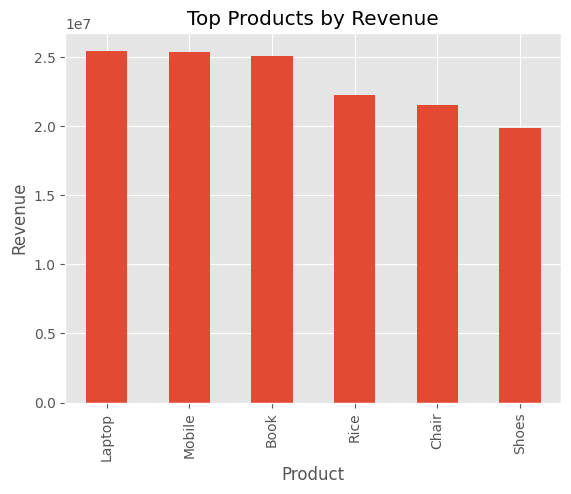

In [19]:
product_sales = df.groupby(
    'Product'
)['Total_Sales'].sum()

product_sales.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title('Top Products by Revenue')
plt.ylabel('Revenue')
plt.show()

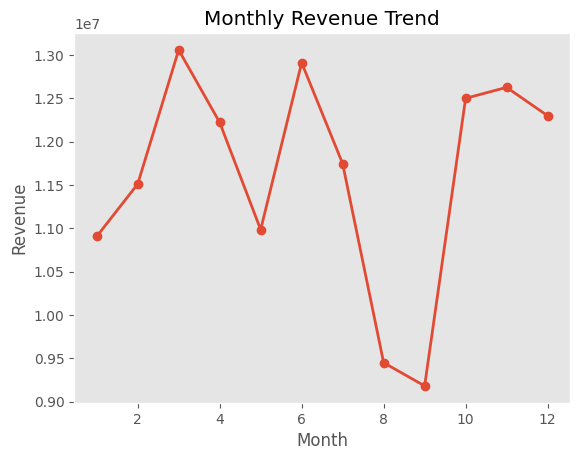

In [20]:
df['Order_Date'] = pd.to_datetime(
    df['Order_Date']
)

df['Month'] = df['Order_Date'].dt.month

monthly_sales = df.groupby(
    'Month'
)['Total_Sales'].sum()

monthly_sales.plot(
    marker='o',
    linewidth=2
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid()
plt.show()

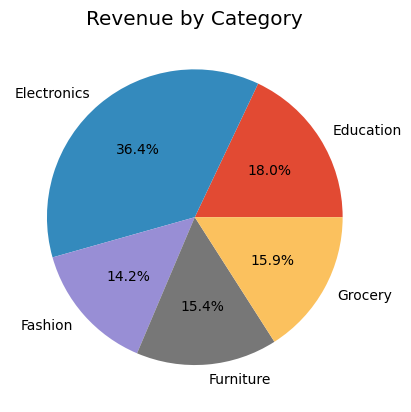

In [21]:
category_sales = df.groupby(
    'Category'
)['Total_Sales'].sum()

category_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Revenue by Category')
plt.ylabel('')
plt.show()

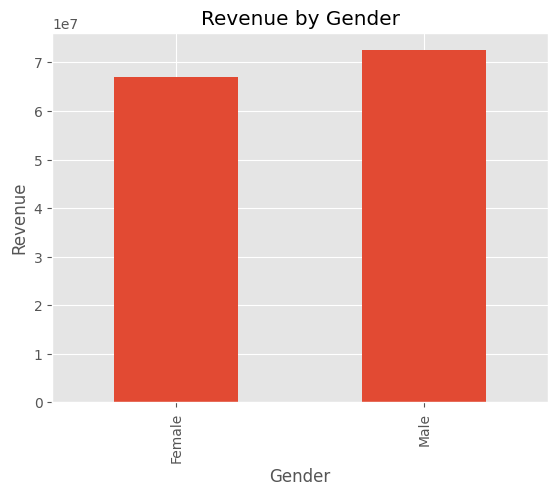

In [22]:
gender_sales = df.groupby(
    'Gender'
)['Total_Sales'].sum()

gender_sales.plot(kind='bar')

plt.title('Revenue by Gender')
plt.ylabel('Revenue')
plt.show()

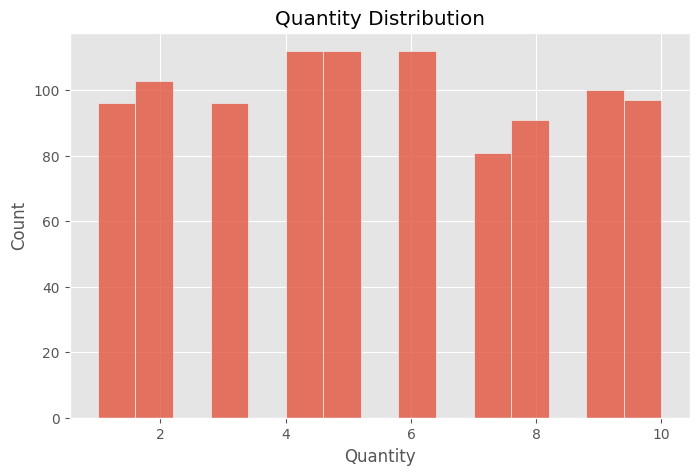

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['Quantity'], bins=15)
plt.title('Quantity Distribution')
plt.show()

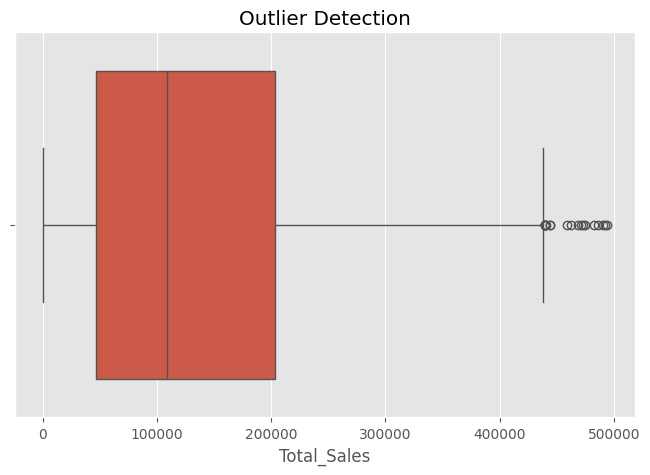

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Total_Sales'])
plt.title('Outlier Detection')
plt.show()

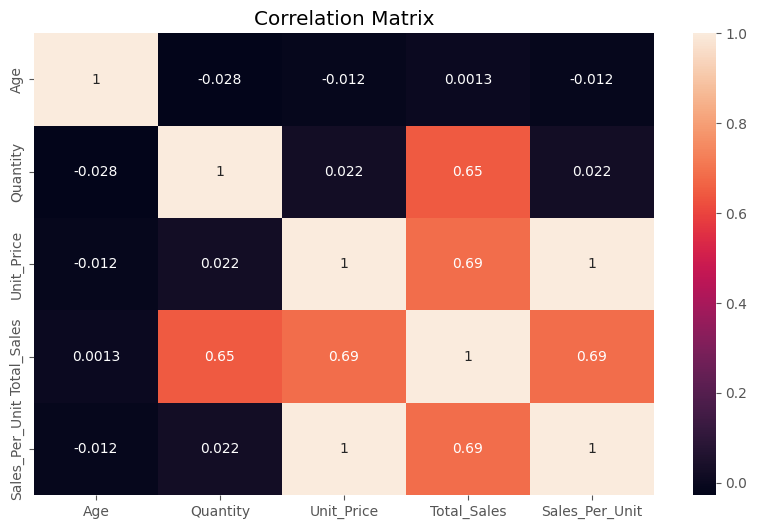

In [25]:
numeric_df = df.select_dtypes(
    include=['int64','float64']
)

plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title(
    'Correlation Matrix'
)
plt.show()

In [26]:
top_products = df.groupby(
    'Product'
)['Total_Sales'].sum()

top_products.sort_values(
    ascending=False
).head(5)

,Total_Sales
Product,
Laptop,25443008.51
Mobile,25335573.19
Book,25031689.40
Rice,22231711.28
Chair,21521561.48


In [27]:
top_cities = df.groupby(
    'City'
)['Total_Sales'].sum()

top_cities.sort_values(
    ascending=False
).head(5)

,Total_Sales
City,
Patna,20826584.43
Kolkata,18884349.57
Bengaluru,18773574.32
Mumbai,18757050.17
Hyderabad,17166766.87


In [28]:
df.groupby(
    'Category'
)['Total_Sales'].sum().sort_values(
    ascending=False
)

,Total_Sales
Category,
Electronics,50778581.70
Education,25031689.40
Grocery,22231711.28
Furniture,21521561.48
Fashion,19835895.79


In [29]:
print(
    "Average Order Value:",
    df['Total_Sales'].mean()
)

Average Order Value: 139399.43965000001


In [30]:
print(
    "Total Revenue:",
    df['Total_Sales'].sum()
)

Total Revenue: 139399439.65


In [31]:
print("Total Revenue:", df['Total_Sales'].sum())
print("Average Revenue:", df['Total_Sales'].mean())
print("Total Orders:", len(df))
print("Unique Customers:", df['Customer_ID'].nunique())

Total Revenue: 139399439.65
Average Revenue: 139399.43965000001
Total Orders: 1000
Unique Customers: 947


In [32]:
business_summary = pd.DataFrame({
    "Metric":[
        "Total Revenue",
        "Average Revenue",
        "Total Orders"
    ],
    "Value":[
        df['Total_Sales'].sum(),
        df['Total_Sales'].mean(),
        len(df)
    ]
})

business_summary.to_csv(
    "business_summary.csv",
    index=False
)